# Qwen 3.5 4B image-text fine-tuning using the LaTeX OCR dataset

[self-link](https://colab.research.google.com/drive/1TUR3OqHqm0E9SrhvBOER1ehqWlxfL0pS)

[Qwen3.5 Fine-tuning Guide](https://unsloth.ai/docs/models/qwen3.5/fine-tune)

[Qwen3.5-4B in Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(4B)_Vision.ipynb)

[LaTeX OCR dataset](https://huggingface.co/datasets/unsloth/LaTeX_OCR)

## Install Unsloth

In [ ]:
#%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==5.3.0
!pip install --no-deps trl==0.22.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.6/401.6 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import unsloth

print(f"Unsloth version: {unsloth.__version__}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth version: 2026.3.8


## Import libraries. Helper functions

In [ ]:
import unsloth # must be the very first import
import torch
import matplotlib.pyplot as plt

# unsloth libraries + helper libraries
from trl import SFTTrainer, SFTConfig
from unsloth import FastVisionModel, is_bf16_supported  # FastLanguageModel for LLMs
from unsloth.trainer import UnslothVisionDataCollator

from datasets import load_dataset
from transformers import TextStreamer
from IPython.display import display, Math, Latex


INSTRUCTION = "Write the LaTeX representation for this image."


def show(image):
    """ Show image using matplotlib """
    fig = plt.figure(figsize=(5, 1.5))
    plt.imshow(image)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def latex_to_image(latex_str):
    """ Convert LaTeX text string to the image """
    # Remove special char '$' and substrings
    clean_text = (
        latex_str.replace("\n", "")
                 .replace("```latex", "")
                 .replace("```", "")
                 .replace("$", "")
                 .strip()
    )
    # print(clean_text)  # show text

    try:
        display(Math(clean_text))
    except Exception as e:
        print(f"Can not show image. Error: {type(e).__name__} — {e}")
        return


def generate(idx, dataset):
    """ Generate prediction """
    img = dataset[idx]["image"]
    txt = dataset[idx]["text"]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": INSTRUCTION},

            ]
        }
    ]

    request = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize = False,
    )

    inputs = tokenizer(
        img,
        request,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to("cuda")

    # text_streamer = TextStreamer(tokenizer, skip_prompt=True)  # show text in stream

    FastVisionModel.for_inference(model) # enable model for inference

    with torch.inference_mode():  # set PyTorch inference mode
        # We use `min_p = 0.1` and `temperature = 1.5`.
        # Read this Tweet for more information on why:
        #   https://x.com/menhguin/status/1826132708508213629
        outputs = model.generate(
            **inputs,
            # streamer = text_streamer,
            max_new_tokens = 128,  # 128 tokens ≈ 512 chars
            use_cache = True,
            temperature = 1.5,     # t=1.5 more random
            min_p = 0.1,           # only > 10% tokens will be used for temperature
            pad_token_id = tokenizer.eos_token_id,
    )

    response_tokens = outputs[:, inputs.input_ids.shape[1]:]
    generated_txt = tokenizer.batch_decode(response_tokens, skip_special_tokens=True)[0]
    generated_txt = generated_txt.strip("$\n ")

    print(f"\n----------------\nGenerated:\t{generated_txt}")
    print(f"Actual:\t\t{txt}\n----------------\n")

    latex_to_image(generated_txt)
    print()
    display(Math(txt))
    # show(img)


def convert_to_json(sample):
    """ JSON text for the LLM model """
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": INSTRUCTION},
                {"type": "image", "image": sample["image"]}
            ]
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": sample["text"]}]
        }
    ]
    return {"messages": messages}

## Download the model

In [ ]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-4B",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2026.3.8: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/336 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 32,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


In [ ]:
# Show model architecture
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3_5ForConditionalGeneration(
      (model): Qwen3_5Model(
        (visual): Qwen3_5VisionModel(
          (patch_embed): Qwen3_5VisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3_5VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3_5VisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3_5VisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=3072, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_

<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [ ]:
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

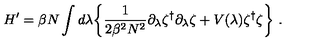

<IPython.core.display.Math object>

In [ ]:
display(dataset)
display(dataset[2]["image"])

# Render the LaTeX in the browser directly
latex = dataset[2]["text"]
display(Math(latex))

## Prepare the dataset

In [ ]:
# Make large JSON file
converted_dataset = [convert_to_json(sample) for sample in dataset]

In [ ]:
# Show the structure of the conversation
display(converted_dataset[1])

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=120x50>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'D _ { \\mu } ^ { \\alpha \\beta } \\bar { A } _ { \\mu } ^ { \\alpha \\beta } = 0 ,'}]}]}

## Check the untrained model

In [ ]:
for i in range(10):
    generate(i, dataset)


----------------
Generated:	{ \frac { N } { M } } \in \mathbf { Z } , { \frac { M } { P } } \in \mathbf { Z } , { \frac { P } { Q } } \in \mathbf { Z }
Actual:		{ \frac { N } { M } } \in { \bf Z } , { \frac { M } { P } } \in { \bf Z } , { \frac { P } { Q } } \in { \bf Z }
----------------



<IPython.core.display.Math object>

<IPython.core.display.Math object>


----------------
Generated:	D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,
Actual:		D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,
----------------



<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>


----------------
Generated:	u _ { \mathrm { t o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P l } } ) + \gamma _ { i } \right] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,
Actual:		u _ { \mathrm { t o t } } = { \frac { 1 } { a ^ { 4 } } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P l } } ) + \gamma _ { i } \right] \approx { \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } } ,
----------------



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<a name="Train"></a>
## Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
FastVisionModel.for_training(model)  # enable model for training

bf16 = is_bf16_supported()
print(f"bf16 == {bf16}")

args = SFTConfig(  # configuration arguments for the trainer
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1,  # set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        fp16 = not bf16,         # bf16 == True, if GPU model is RTX 30+
        bf16 = bf16,             # try Bfloat16 (Brain Floating Point) for GPU
        logging_steps = 1,       # if 1, then log every step
        optim = "adamw_8bit",
        weight_decay = 0.001,    # penalizes the large weights
        lr_scheduler_type = "linear",  # after warmup lineary decrease LR to zero
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases
        dataset_num_proc=4,     # number of workers

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    )

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = args,
)

bf16 == False
Unsloth: Model does not have a default image size - using 512
Unsloth: Switching to float32 training since model cannot work with float16


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
9.68 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 38,756,352 of 4,578,021,888 (0.85% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.699990
2,0.861260
3,0.583029
4,0.396827
5,0.276413
6,0.185126
7,0.143591
8,0.076254
9,0.053570
10,0.064818


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

403.5555 seconds used for training.
6.73 minutes used for training.
Peak reserved memory = 9.68 GB.
Peak reserved memory for training = 0.0 GB.
Peak reserved memory % of max memory = 66.47 %.
Peak reserved memory for training % of max memory = 0.0 %.


<a name="Inference"></a>
### Inference

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [ ]:
for i in range(10):
    generate(i, dataset)


----------------
Generated:	\frac { N } { M } \in { \bf Z } , \frac { M } { P } \in { \bf Z } , \frac { P } { Q } \in { \bf Z }
Actual:		{ \frac { N } { M } } \in { \bf Z } , { \frac { M } { P } } \in { \bf Z } , { \frac { P } { Q } } \in { \bf Z }
----------------



<IPython.core.display.Math object>

<IPython.core.display.Math object>


----------------
Generated:	D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,
Actual:		D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,
----------------



<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>


----------------
Generated:	u _ { \mathrm { t o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } [ \alpha _ { i } \ln ( a / L _ { \mathrm { P 1 } } ) + \gamma _ { i } ] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,
Actual:		u _ { \mathrm { t o t } } = { \frac { 1 } { a ^ { 4 } } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P l } } ) + \gamma _ { i } \right] \approx { \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } } ,
----------------



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<a name="Save"></a>
## Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("qwen_lora")  # Local saving
tokenizer.save_pretrained("qwen_lora")
# model.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving

['qwen_lora/processor_config.json']